# Titanic Dataset: Data Cleaning and Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/titanic.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [4]:
df.info()
print("\n")
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      

## Check Missing Values

In [5]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


## Handle Missing Values

In [6]:
# Fill missing age values with median
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

# Fill missing embarked values with most common value
most_common_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(most_common_embarked)

# Fill missing embark_town values with most common value
most_common_embark_town = df['embark_town'].mode()[0]
df['embark_town'] = df['embark_town'].fillna(most_common_embark_town)

# Drop deck column because most values are missing
df.drop('deck', axis=1, inplace=True)

print("Missing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after handling:
Series([], dtype: int64)


## Check and Remove Duplicates

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 116
Duplicates removed. New shape: (775, 14)


## Show Summary Statistics

## Visualization 1: Survival Count

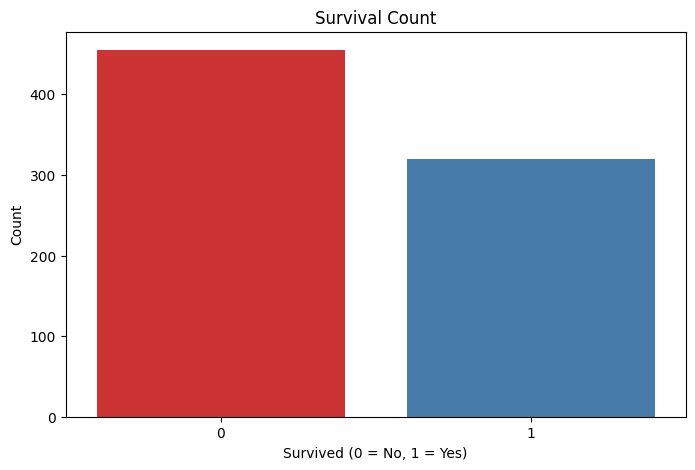

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='survived', hue='survived', data=df, palette='Set1', legend=False)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Visualization 2: Gender Distribution

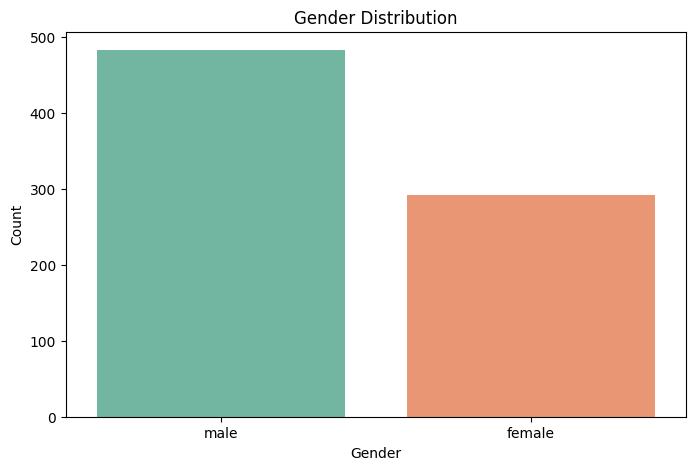

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='sex', data=df, palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## Visualization 3: Age Distribution

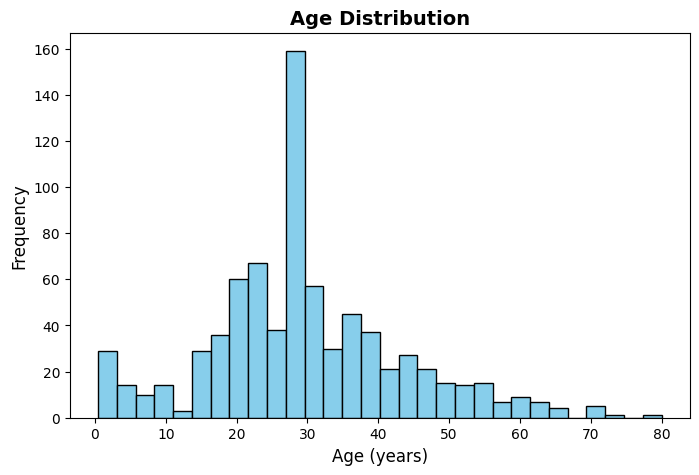

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## Visualization 4: Passenger Class Distribution

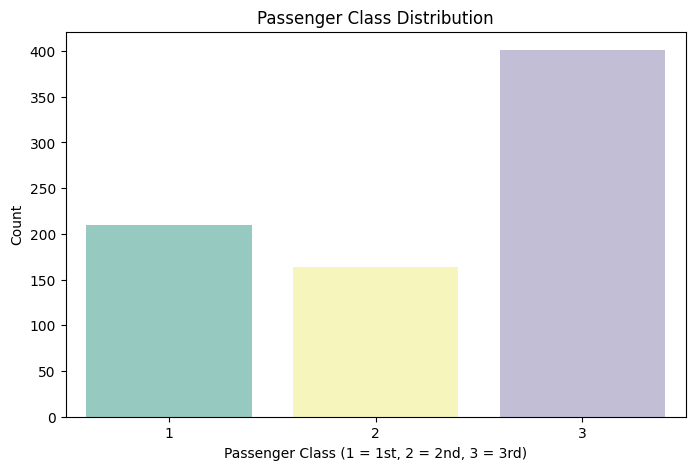

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x='pclass', hue='pclass', data=df, palette='Set3', legend=False)
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Count')
plt.show()

## Visualization 5: Survival by Gender

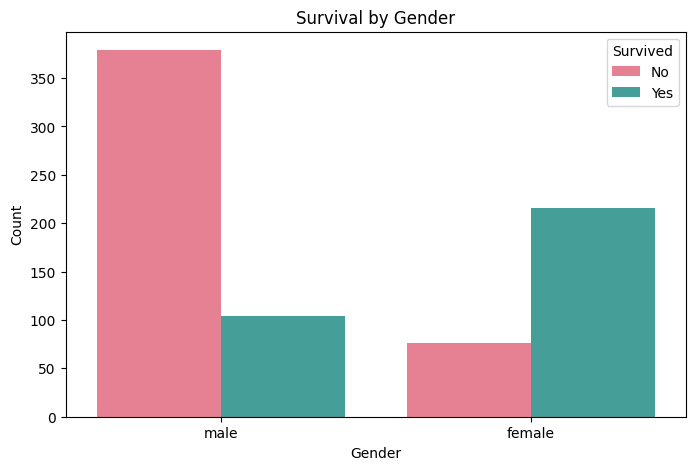

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='survived', data=df, palette='husl')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## Correlation Heatmap

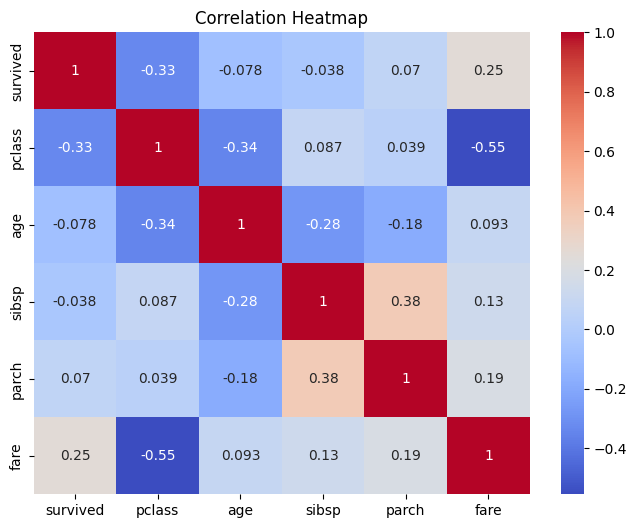

In [13]:
correlation_matrix = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Final Insights

In [14]:
print("Survival by Gender:")
female_survival = (df[df['sex'] == 'female']['survived'].sum() / len(df[df['sex'] == 'female'])) * 100
male_survival = (df[df['sex'] == 'male']['survived'].sum() / len(df[df['sex'] == 'male'])) * 100
print(f"Female: {female_survival:.1f}%")
print(f"Male: {male_survival:.1f}%")

print("\nSurvival by Class:")
for pclass in [1, 2, 3]:
    class_survival = (df[df['pclass'] == pclass]['survived'].sum() / len(df[df['pclass'] == pclass])) * 100
    print(f"Class {pclass}: {class_survival:.1f}%")

print(f"\nAge - Mean: {df['age'].mean():.1f}, Median: {df['age'].median():.1f}")

Survival by Gender:
Female: 74.0%
Male: 21.5%

Survival by Class:
Class 1: 63.3%
Class 2: 50.6%
Class 3: 25.9%

Age - Mean: 29.6, Median: 28.0
